In [1]:
# =====================================================================
# CELL 1: SETUP & BATCHED DATA PREP (RAW TVS ONLY)
# =====================================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import json
import re
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

embedder = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
print("SentenceTransformer loaded.")

from google.colab import drive
drive.mount('/content/drive')

NUM_SEEDS_TO_USE = 2

print(f"Loading Trajectories from Google Drive...")
dataset = np.load("/content/drive/MyDrive/dream/tvs_master_variance_arrays_extra.npz")
clean_traj = dataset['clean_traj']
conflict_traj = dataset['conflict_traj']

print("Loading Verified Master Dataset for base sentences...")
with open("/content/drive/MyDrive/dream/verified_master_dataset.json", "r") as f:
    verified_eval_facts = json.load(f)

NUM_FACTS = clean_traj.shape[0]

# --- FAST BATCHED VARIANCE RECALCULATION ---
print(f"Recalculating Semantic Variance for {NUM_SEEDS_TO_USE} seeds...")
clean_raw_k, conflict_raw_k = [], []

for i in tqdm(range(NUM_FACTS), desc=f"Calculating Embeddings"):
    base_sentence = verified_eval_facts[i]["base"]

    c_traj_k = clean_traj[i, :NUM_SEEDS_TO_USE, :]
    conf_traj_k = conflict_traj[i, :NUM_SEEDS_TO_USE, :]
    K = c_traj_k.shape[0]

    c_flat = c_traj_k.T.flatten()
    conf_flat = conf_traj_k.T.flatten()
    all_texts = np.concatenate([c_flat, conf_flat])

    isolated_entities = []
    for text in all_texts:
        raw_answer = text.split(base_sentence)[-1] if base_sentence in text else text
        clean_answer = re.sub(r'[^a-zA-Z0-9\s]', '', raw_answer).strip().lower()
        isolated_entities.append(clean_answer if clean_answer else "[EMPTY_TOKEN]")

    embeddings = embedder.encode(isolated_entities, batch_size=200, show_progress_bar=False)

    c_vars, conf_vars = [], []
    for step in range(50):
        start_idx = step * K
        step_embs = embeddings[start_idx : start_idx + K]
        dist = 1 - cosine_similarity(step_embs)
        i_idx, j_idx = np.triu_indices(K, k=1)
        c_vars.append(np.clip(dist[i_idx, j_idx].mean(), 0, None))

    offset = 50 * K
    for step in range(50):
        start_idx = offset + (step * K)
        step_embs = embeddings[start_idx : start_idx + K]
        dist = 1 - cosine_similarity(step_embs)
        i_idx, j_idx = np.triu_indices(K, k=1)
        conf_vars.append(np.clip(dist[i_idx, j_idx].mean(), 0, None))

    clean_raw_k.append(c_vars)
    conflict_raw_k.append(conf_vars)

clean_raw = np.array(clean_raw_k)
conflict_raw = np.array(conflict_raw_k)

print(f"Data Prep Complete!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SentenceTransformer loaded.
Mounted at /content/drive
Loading Trajectories from Google Drive...
Loading Verified Master Dataset for base sentences...
Recalculating Semantic Variance for 2 seeds...


Calculating Embeddings: 100%|██████████| 2370/2370 [04:43<00:00,  8.37it/s]

Data Prep Complete!


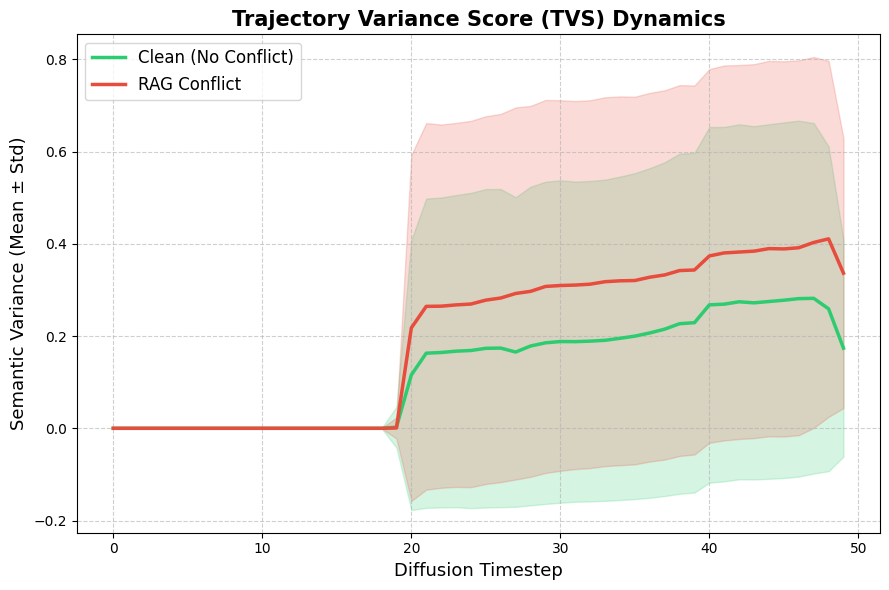

Graph saved successfully!


In [2]:
# =====================================================================
# CELL 2: TEMPORAL DYNAMICS VISUALIZATION (RAW TVS ONLY)
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np

# Calculate Means and Standard Deviations across all generated facts
# Shape of clean_raw: (NUM_FACTS, 50 timesteps)

# Raw Variance Stats
mean_clean_raw = np.mean(clean_raw, axis=0)
std_clean_raw = np.std(clean_raw, axis=0)

mean_conflict_raw = np.mean(conflict_raw, axis=0)
std_conflict_raw = np.std(conflict_raw, axis=0)

steps = np.arange(50)

# Create a single figure for the raw TVS dynamics
plt.figure(figsize=(9, 6))

# --- PLOT: RAW SEMANTIC VARIANCE (TVS) OVER TIME ---
plt.plot(steps, mean_clean_raw, label="Clean (No Conflict)", color="#2ecc71", linewidth=2.5)
# Error bars (shaded region)
plt.fill_between(steps, mean_clean_raw - std_clean_raw, mean_clean_raw + std_clean_raw, color="#2ecc71", alpha=0.2)

plt.plot(steps, mean_conflict_raw, label="RAG Conflict", color="#e74c3c", linewidth=2.5)
# Error bars (shaded region)
plt.fill_between(steps, mean_conflict_raw - std_conflict_raw, mean_conflict_raw + std_conflict_raw, color="#e74c3c", alpha=0.2)

plt.title("Trajectory Variance Score (TVS) Dynamics", fontsize=15, fontweight='bold')
plt.xlabel("Diffusion Timestep", fontsize=13)
plt.ylabel("Semantic Variance (Mean ± Std)", fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

# Save the high-res figure for the paper
plt.savefig("/content/drive/MyDrive/dream/tvs_raw_dynamics_with_errorbars.png", dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved successfully!")

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from torch.utils.data import TensorDataset, DataLoader

from google.colab import drive
drive.mount('/content/drive')

NUM_SEEDS_TO_USE = 2

print(f"Loading Trajectories from Google Drive...")
dataset = np.load("/content/drive/MyDrive/dream/tvs_master_variance_arrays_extra.npz")
clean_raw = dataset['clean_raw']
conflict_raw = dataset['conflict_raw']
NUM_FACTS = clean_raw.shape[0]

X_list, y_list = [], []
for i in range(NUM_FACTS):
    # Only append the LAST timestep (index 49)
    X_list.append([clean_raw[i, -1]])
    y_list.append(0)
    X_list.append([conflict_raw[i, -1]])
    y_list.append(1)

X = torch.tensor(np.array(X_list), dtype=torch.float32)
y = torch.tensor(y_list, dtype=torch.float32).unsqueeze(1)
indices = torch.arange(len(y))

class LogisticRegressionModel(nn.Module):
    def __init__(self):
        super(LogisticRegressionModel, self).__init__()
        self.fc = nn.Linear(1, 1)

    def forward(self, x):
        return torch.sigmoid(self.fc(x))

acc_list = []
NUM_RUNS = 5
for run in range(NUM_RUNS):
    X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(X, y, indices, test_size=0.30, random_state=42+run, stratify=y)
    X_val, X_test, y_val, y_test, idx_val, idx_test = train_test_split(X_temp, y_temp, idx_temp, test_size=0.50, random_state=42+run, stratify=y_temp)

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64, shuffle=False)

    model = LogisticRegressionModel()
    criterion = nn.BCELoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=75)

    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(75):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        scheduler.step()

        model.eval()
        val_loss_accum = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                val_loss_accum += criterion(model(batch_X), batch_y).item() * batch_X.size(0)
        avg_val_loss = val_loss_accum / len(X_val)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict().copy()

    model.load_state_dict(best_model_state)
    model.eval()
    with torch.no_grad():
        test_probs = model(X_test)
        test_preds = (test_probs >= 0.5).float()

    acc = accuracy_score(y_test.numpy(), test_preds.numpy())
    acc_list.append(acc * 100)

print(f"Mean Accuracy: {np.mean(acc_list):.2f}% +/- {np.std(acc_list):.2f}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Trajectories from Google Drive...
Mean Accuracy: 67.90% +/- 1.59%
